In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [9]:
# Đọc dữ liệu đã chuẩn hóa
df = pd.read_csv("milk_standard_scaler.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (1059, 8)


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,-0.021531,-0.914107,0.910503,-0.872962,0.699608,-0.982217,0.501600,2
1,-0.021531,-0.815035,-1.098294,1.145525,-1.429372,1.018105,0.269333,2
2,1.336564,2.553438,0.910503,1.145525,0.699608,1.018105,-1.356536,0
3,2.051351,-1.013180,0.910503,1.145525,-1.429372,1.018105,0.733867,0
4,-0.021531,-0.715962,-1.098294,-0.872962,-1.429372,-0.982217,0.733867,1


In [10]:
# Tách dữ liệu
X = df.drop("Grade", axis=1)
y = df["Grade"]

In [11]:
# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (847, 7)
Test : (212, 7)


In [12]:
# Thử nhiều cấu hình Random Forest
models = [
    {
        "n_estimators": 50,
        "max_depth": 5
    },
    {
        "n_estimators": 100,
        "max_depth": 5
    },
    {
        "n_estimators": 100,
        "max_depth": 10
    },
    {
        "n_estimators": 200,
        "max_depth": 10
    },
    {
        "n_estimators": 300,
        "max_depth": None
    },
    {
        "n_estimators": 500,
        "max_depth": None
    }
]

results = []

best_model = None
best_f1 = 0

In [13]:
# Huấn luyện và đánh giá
for config in models:

    rf = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        config["n_estimators"],
        config["max_depth"],
        acc,
        precision,
        recall,
        f1
    ])

    print("=" * 50)
    print(config)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model = rf
        best_config = config


{'n_estimators': 50, 'max_depth': 5}
Accuracy : 0.9670
Precision: 0.9686
Recall   : 0.9670
F1-score : 0.9667
{'n_estimators': 100, 'max_depth': 5}
Accuracy : 0.9670
Precision: 0.9686
Recall   : 0.9670
F1-score : 0.9667
{'n_estimators': 100, 'max_depth': 10}
Accuracy : 0.9953
Precision: 0.9954
Recall   : 0.9953
F1-score : 0.9953
{'n_estimators': 200, 'max_depth': 10}
Accuracy : 0.9953
Precision: 0.9954
Recall   : 0.9953
F1-score : 0.9953
{'n_estimators': 300, 'max_depth': None}
Accuracy : 0.9953
Precision: 0.9954
Recall   : 0.9953
F1-score : 0.9953
{'n_estimators': 500, 'max_depth': None}
Accuracy : 0.9953
Precision: 0.9954
Recall   : 0.9953
F1-score : 0.9953


In [14]:
# Bảng kết quả
results_df = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "max_depth",
        "accuracy",
        "precision",
        "recall",
        "f1_score"
    ]
)

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
)

print("\n===== KẾT QUẢ TỔNG HỢP =====")
display(results_df)


===== KẾT QUẢ TỔNG HỢP =====


,n_estimators,max_depth,accuracy,precision,recall,f1_score
2,100,10.0,0.995283,0.995374,0.995283,0.995292
3,200,10.0,0.995283,0.995374,0.995283,0.995292
4,300,NaN,0.995283,0.995374,0.995283,0.995292
5,500,NaN,0.995283,0.995374,0.995283,0.995292
0,50,5.0,0.966981,0.968565,0.966981,0.966661
1,100,5.0,0.966981,0.968565,0.966981,0.966661


In [15]:
#Mô hình tốt nhất
print("\n===== BEST MODEL =====")
print(best_config)
print("Best F1-score =", best_f1)


===== BEST MODEL =====
{'n_estimators': 100, 'max_depth': 10}
Best F1-score = 0.9952921244920935


In [16]:
# Đánh giá chi tiết
y_pred_best = best_model.predict(X_test)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_best
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        y_pred_best
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        86
           1       1.00      1.00      1.00        75
           2       0.98      1.00      0.99        51

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212


Confusion Matrix
[[85  0  1]
 [ 0 75  0]
 [ 0  0 51]]


In [17]:
# Feature Importance
# ==========================================
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop đặc trưng quan trọng:")
display(importance_df)


Top đặc trưng quan trọng:


,Feature,Importance
0,pH,0.408160
1,Temprature,0.231264
4,Fat,0.094720
5,Turbidity,0.087817
3,Odor,0.077177
6,Colour,0.061485
2,Taste,0.039376


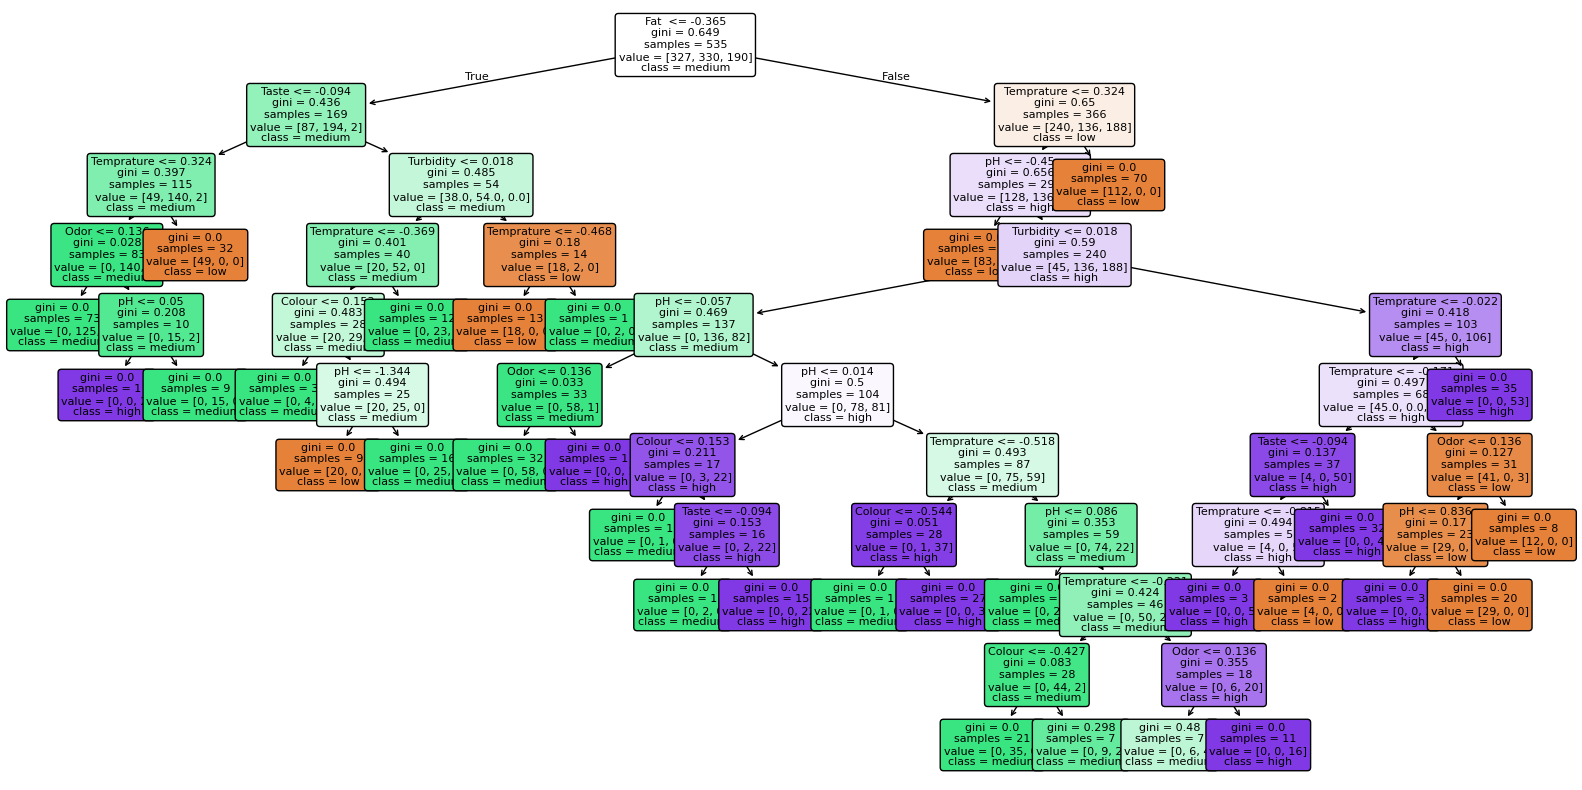

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Lấy cây đầu tiên trong rừng
tree = best_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["low", "medium", "high"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()